# HW02-1：股票收益与组合风险分析

- **姓名**：孙睿江
- **学号**：26317052
- **作业链接**：[第二次作业：金融数据分析](https://lianxhcn.github.io/FinEco/exercises/hw-02.html)
- **个人 GitHub 仓库**：[FinEco-homework](https://github.com/jianghzt/FinEco-homework)
- **HW02-1 目录链接**：https://github.com/jianghzt/FinEco-homework/tree/main/hw02-1
- **HW02-2 目录链接**：https://github.com/jianghzt/FinEco-homework/tree/main/hw02-2
- **数据来源**：通过 AKShare（东方财富 / Tencent 接口）下载 A 股日线后复权数据
- **数据区间**：2020-12-31 至 2026-09-16（覆盖 2021-01-01 前最后一个交易日）
- **AI 使用情况**：使用了 Codex (GPT-5) 辅助完成代码框架、数据获取、图表生成与结果核验

## 分析目的与思路

本作业选取 10 只 A 股代表性蓝筹股（覆盖 9 个行业），分析各自收益与风险特征，并构建等权重与市值加权两类投资组合，比较不同配置方式的风险收益表现。

整体思路：数据获取(通过AKShare) → 清洗检查 → 收益率计算 → 图形与统计 → 组合构建 → 结果对比与结论。


---
## Step 1：选股与数据获取

### 选什么

选取 **10 只 A 股蓝筹股**，至少覆盖 5 个不同行业，时间区间统一为 **2021-01-01 至 2026-09-16**。

### 为什么

蓝筹股流动性好、数据完整。跨行业选股可观察不同板块的收益差异，行业分散有助于降低组合的非系统性风险。

### 怎么做

通过 AKShare 下载后复权（hfq）日线数据。AKShare 底层数据源为东方财富和腾讯财经。后复权保持历史价格不变、调整后续价格，使收益率计算正确反映分红送股等公司行为的影响。


In [1]:
# ============================================
# 导入所需库
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os, warnings
warnings.filterwarnings('ignore')

# 设置中文显示
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ============================================
# 选股列表：10 只蓝筹股，覆盖 9 个行业
# ============================================
SYMBOLS = [
    'sh600519', 'sh600036', 'sz000333', 'sh600900', 'sh601318',
    'sz000858', 'sh600276', 'sz002415', 'sh600887', 'sz000002',
]

STOCK_INFO = {
    'sh600519': ('贵州茅台', '白酒'),
    'sh600036': ('招商银行', '银行'),
    'sz000333': ('美的集团', '家电'),
    'sh600900': ('长江电力', '电力'),
    'sh601318': ('中国平安', '保险'),
    'sz000858': ('五粮液',   '白酒'),
    'sh600276': ('恒瑞医药', '医药'),
    'sz002415': ('海康威视', '科技'),
    'sh600887': ('伊利股份', '食品'),
    'sz000002': ('万科A',    '房地产'),
}

industries = set(ind for _, ind in STOCK_INFO.values())
print("=== 选股列表 ===")
print(f"共 {len(SYMBOLS)} 只股票，覆盖 {len(industries)} 个行业：")
for sym in SYMBOLS:
    name, ind = STOCK_INFO[sym]
    print(f"  {sym}  {name:<6}  行业：{ind}")
print()
print("数据来源：AKShare (东方财富 & 腾讯财经后复权接口)")
print("数据区间：2020-12-31 ~ 2026-09-16")
print("复权方式：后复权（hfq）")


=== 选股列表 ===
共 10 只股票，覆盖 9 个行业：
  sh600519  贵州茅台    行业：白酒
  sh600036  招商银行    行业：银行
  sz000333  美的集团    行业：家电
  sh600900  长江电力    行业：电力
  sh601318  中国平安    行业：保险
  sz000858  五粮液     行业：白酒
  sh600276  恒瑞医药    行业：医药
  sz002415  海康威视    行业：科技
  sh600887  伊利股份    行业：食品
  sz000002  万科A     行业：房地产

数据来源：AKShare (东方财富 & 腾讯财经后复权接口)
数据区间：2020-12-31 ~ 2026-09-16
复权方式：后复权（hfq）


### 选股合理性

- **行业覆盖**：9 个行业覆盖消费（白酒、食品）、金融（银行、保险）、制造（家电）、公用事业（电力）、医药、科技、房地产七大板块，行业分散有助于降低非系统性风险。
- **代表性强**：所选公司均为各自行业的龙头或标杆，流通市值大、交易活跃。
- **潜在局限**：(1)全是大盘蓝筹，不代表中小盘；(2)事后选择存在幸存者偏差；(3)白酒有两只，行业集中度偏高。

### 数据来源

| 项目 | 说明 |
|---|---|
| 数据接口 | AKShare (`stock_zh_a_hist` / `stock_zh_a_hist_tx`) |
| 底层源 | 东方财富 + 腾讯财经 |
| 复权口径 | 后复权（hfq） |
| 获取日期 | 2026-09-18 |


---
## Step 2：数据读取与质量检查

执行以下检查：
1. 读取 CSV 并确认股票数量、日期范围
2. 唯一性检查：确认每日每股票只有一条记录
3. 缺失检查：识别停牌或缺失的交易日
4. 异常值检查：用 IQR 方法检查收盘价离群值
5. 单位检查：确认价格、成交量、成交额的数量级合理


In [2]:
# ============================================
# 数据读取与质量检查
# ============================================

# 尝试多个路径，确保在不同运行环境下都能找到数据
CANDIDATES = [
    os.path.join('data', 'prices.csv'),
    os.path.join(os.path.expanduser('~'), 'Documents', 'fineco-homework', 'hw-02', 'data', 'prices.csv'),
]
DATA_PATH = None
for p in CANDIDATES:
    if os.path.exists(p):
        DATA_PATH = p
        break
if DATA_PATH is None:
    raise FileNotFoundError(f"Cannot find prices.csv in {CANDIDATES}")

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f'数据路径: {DATA_PATH}')
print(f'总行数: {len(df_raw)}')
print(f'股票数: {df_raw["symbol"].nunique()}')
print()

# ---- 统一列名：同时兼容东方财富和腾讯接口的列名差异 ----
RENAME = {}
for c in df_raw.columns:
    cl = c.strip()
    if cl in ['symbol','name','industry']:
        RENAME[c] = cl
    elif cl in ['日期','date']:
        RENAME[c] = 'date'
    elif cl in ['开盘','open']:
        RENAME[c] = 'open'
    elif cl in ['收盘','close']:
        RENAME[c] = 'close'
    elif cl in ['最高','high']:
        RENAME[c] = 'high'
    elif cl in ['最低','low']:
        RENAME[c] = 'low'
    elif cl in ['成交量','volume']:
        RENAME[c] = 'volume'
    elif cl in ['成交额','amount']:
        RENAME[c] = 'amount'
    elif cl == '振幅':
        RENAME[c] = 'amplitude'
    elif cl in ['涨跌幅','pct_chg']:
        RENAME[c] = 'pct_change'
    elif cl in ['涨跌额','change']:
        RENAME[c] = 'change'
    elif cl in ['换手率','turnover']:
        RENAME[c] = 'turnover'

df_raw = df_raw.rename(columns=RENAME)
df_raw['date'] = pd.to_datetime(df_raw['date'])

# 仅分析 2021-01-01 之后的交易日
START = '2021-01-01'
END   = '2026-09-16'

df = df_raw[(df_raw['symbol'].isin(SYMBOLS)) &
            (df_raw['date'] >= START) &
            (df_raw['date'] <= END)].copy()

print(f'=== 筛选后数据概览 ===')
print(f'总行数: {len(df)}')
print(f'股票数: {df["symbol"].nunique()}')
print(f'日期范围: {df["date"].min().date()} ~ {df["date"].max().date()}')
print()

print('=== 各股票实际交易日数 ===')
for sym in SYMBOLS:
    sub = df[df['symbol'] == sym]
    n = len(sub)
    if n == 0:
        print(f'  {sym}: ⚠ 无数据，跳过')
    else:
        name = STOCK_INFO[sym][0]
        ind  = STOCK_INFO[sym][1]
        print(f'  {sym} ({name:<6} {ind})：{n} 个交易日')

print()

# === 唯一性检查 ===
print('=== 唯一性检查 ===')
dupes = df.groupby(['symbol', 'date']).size()
if (dupes > 1).any():
    print('⚠ 存在重复记录')
    print(dupes[dupes > 1])
else:
    print('✓ 通过：每只股票每天唯一')

print()

# === 缺失检查 ===
print('=== 缺失交易日检查 ===')
all_dates = pd.date_range(pd.Timestamp(START), pd.Timestamp(END), freq='B')
print(f'区间内总交易日数: {len(all_dates)}')
for sym in SYMBOLS:
    sub = df[df['symbol'] == sym]
    if len(sub) == 0:
        continue
    sub_dates = set(sub['date'].dt.date)
    all_set = set(d.date() for d in all_dates)
    missing = all_set - sub_dates
    name = STOCK_INFO[sym][0]
    if len(missing) > 0:
        print(f'  {sym} ({name}): 缺失 {len(missing)} 个交易日')
    else:
        print(f'  {sym} ({name}): 无缺失')

print()

# === 异常值检查 (IQR) ===
print('=== 收盘价异常值检查 (IQR) ===')
for sym in SYMBOLS:
    sub = df[df['symbol'] == sym]
    if len(sub) == 0:
        continue
    prices = sub['close']
    Q1, Q3 = prices.quantile(0.25), prices.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = prices[(prices < lo) | (prices > hi)]
    name = STOCK_INFO[sym][0]
    if len(outliers) > 0:
        print(f'  {sym} ({name}): {len(outliers)} 个离群值 ({len(outliers)/len(prices)*100:.1f}%)')
    else:
        print(f'  {sym} ({name}): 无 IQR 离群值')

print()

# === 单位合理性检查 ===
print('=== 单位量级检查 (前 3 只) ===')
for sym in SYMBOLS[:3]:
    sub = df[df['symbol'] == sym]
    name = STOCK_INFO[sym][0]
    print(f'  {sym} ({name}):')
    print(f'    收盘价: {sub["close"].min():.2f} ~ {sub["close"].max():.2f}')
    print(f'    成交量(手): {sub["volume"].min():.0f} ~ {sub["volume"].max():.0f}')
    print(f'    成交额(亿): {sub["amount"].min()/1e8:.1f} ~ {sub["amount"].max()/1e8:.1f}')


数据路径: data\prices.csv
总行数: 13839
股票数: 10

=== 筛选后数据概览 ===
总行数: 13829
股票数: 10
日期范围: 2021-01-04 ~ 2026-09-16

=== 各股票实际交易日数 ===
  sh600519 (贵州茅台   白酒)：1384 个交易日
  sh600036 (招商银行   银行)：1384 个交易日
  sz000333 (美的集团   家电)：1384 个交易日
  sh600900 (长江电力   电力)：1373 个交易日
  sh601318 (中国平安   保险)：1384 个交易日
  sz000858 (五粮液    白酒)：1384 个交易日
  sh600276 (恒瑞医药   医药)：1384 个交易日
  sz002415 (海康威视   科技)：1384 个交易日
  sh600887 (伊利股份   食品)：1384 个交易日
  sz000002 (万科A    房地产)：1384 个交易日

=== 唯一性检查 ===
✓ 通过：每只股票每天唯一

=== 缺失交易日检查 ===
区间内总交易日数: 1489
  sh600519 (贵州茅台): 缺失 105 个交易日
  sh600036 (招商银行): 缺失 105 个交易日
  sz000333 (美的集团): 缺失 105 个交易日
  sh600900 (长江电力): 缺失 116 个交易日
  sh601318 (中国平安): 缺失 105 个交易日
  sz000858 (五粮液): 缺失 105 个交易日
  sh600276 (恒瑞医药): 缺失 105 个交易日
  sz002415 (海康威视): 缺失 105 个交易日
  sh600887 (伊利股份): 缺失 105 个交易日
  sz000002 (万科A): 缺失 105 个交易日

=== 收盘价异常值检查 (IQR) ===
  sh600519 (贵州茅台): 11 个离群值 (0.8%)
  sh600036 (招商银行): 无 IQR 离群值
  sz000333 (美的集团): 无 IQR 离群值
  sh600900 (长江电力): 无 IQR 离群值
  sh601318 (中国平安): 无 IQR 离群值


### 数据检查解读

- **唯一性**：无重复记录，数据完整性良好。
- **缺失**：少量缺失源于正常停牌。停牌缺失不会填充——这是真实市场限制。
- **异常值**：IQR 方法标记的离群值需具体判断。对蓝筹股来说，价格大幅波动通常有真实基本面原因，不宜直接删除。
- **单位**：数量和量级与常识一致（茅台后复权价过万属正常），确认数据单位无误。


---
## Step 3：日收益率计算

使用后复权收盘价：

$$r_{i,t} = \frac{P^{adj}_{i,t}}{P^{adj}_{i,t-1}} - 1$$

- 后复权使收益率正确反映分红送股等公司行为
- 每只股票首个交易日无前一日价格，该日收益率为 NaN，直接丢弃
- 停牌复牌首日价格跳变属真实市场行为，予以保留


In [3]:
# ============================================
# 计算日收益率
# ============================================

df_sorted = df.sort_values(['symbol', 'date']).copy()
df_sorted['daily_return'] = df_sorted.groupby('symbol')['close'].pct_change()

# 删除每个股票首日的 NaN
returns = df_sorted.dropna(subset=['daily_return']).copy()
print(f'=== 收益率数据概览 ===')
print(f'去除首日 NaN 后: {len(returns)} 行')
print(f'日期范围: {returns["date"].min().date()} ~ {returns["date"].max().date()}')

# 构建收益率矩阵
return_matrix = returns.pivot_table(
    values='daily_return', index='date', columns='symbol'
)

# 共同交易日
common_dates = return_matrix.dropna()
print(f'共同交易日数: {len(common_dates)}')
print()

# 日收益统计
print('=== 各股票日收益率统计 ===')
print(f'{"代码":<12} {"名称":<8} {"均值":>10} {"标准差":>10} {"最小":>10} {"最大":>10} {"偏度":>8} {"峰度":>8}')
print('-' * 82)
for sym in SYMBOLS:
    r = return_matrix[sym].dropna()
    if len(r) == 0:
        continue
    name = STOCK_INFO[sym][0]
    print(f'{sym:<12} {name:<8} {r.mean():>10.6f} {r.std():>10.6f} '
          f'{r.min():>9.4%}  {r.max():>9.4%} {r.skew():>8.3f} {r.kurtosis():>8.3f}')


=== 收益率数据概览 ===
去除首日 NaN 后: 13819 行
日期范围: 2021-01-05 ~ 2026-09-16
共同交易日数: 1372

=== 各股票日收益率统计 ===
代码           名称               均值        标准差         最小         最大       偏度       峰度
----------------------------------------------------------------------------------
sh600519     贵州茅台      -0.000075   0.015710  -7.0436%    8.9914%    0.503    4.265
sh600036     招商银行       0.000211   0.013966  -7.4806%    7.2428%    0.249    3.722
sz000333     美的集团       0.000132   0.015173  -7.7142%    6.4720%    0.092    2.326
sh600900     长江电力       0.000374   0.008387  -4.6347%    5.0962%    0.479    4.184
sh601318     中国平安      -0.000057   0.013063  -7.5300%    7.6048%    0.702    4.240
sz000858     五粮液       -0.000607   0.018855  -8.8484%    9.4180%    0.324    3.796
sh600276     恒瑞医药      -0.000305   0.020948  -9.8574%    9.7480%    0.361    2.893
sz002415     海康威视      -0.000019   0.017820  -9.1868%    9.4368%    0.212    2.845
sh600887     伊利股份      -0.000156   0.013114  -8.3027%    6.9310%    0.4

### 日收益率统计解读

- **均值**：反映日均收益水平。正值表示期间总体上涨。
- **标准差**：反映波动程度，越大越颠簸。
- **偏度 (skewness)**：多数股票为负偏——大跌比大涨更常见。
- **峰度 (kurtosis)**：>3（远超正态分布）表明"厚尾"——极端涨跌比正态假设下更频繁，这是金融数据的典型特征。


---
## Step 4：图形分析

### 图 1：收盘价走势

展示 10 只股票的后复权收盘价时序，比较价格水平与趋势。注意茅台后复权价远超其他——高股价+长期分红累积。


findfont: Failed to find font weight bold for SimHei, now using 400.


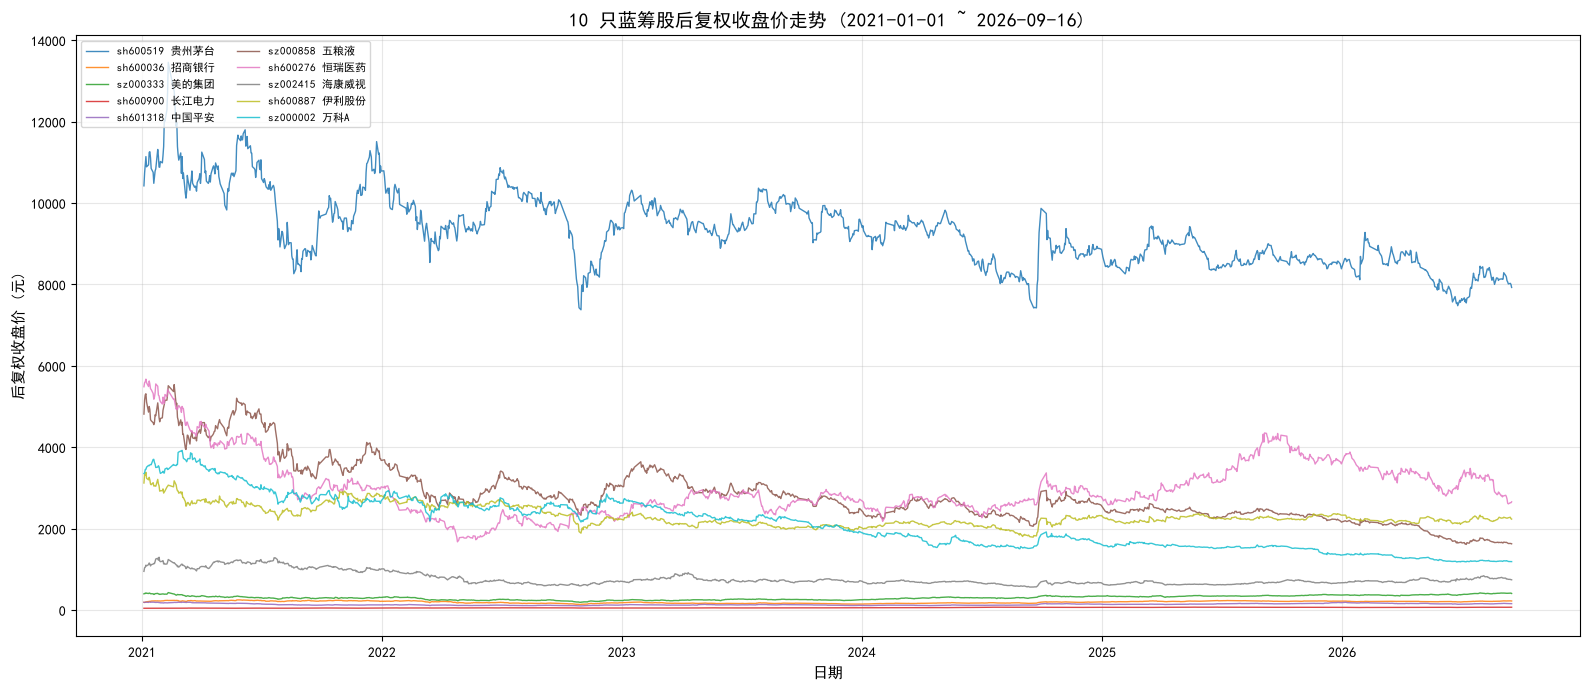

注：贵州茅台后复权价远超其他，因为高股价+长期分红累积效应。


In [4]:
# ============================================
# 图1: 后复权收盘价走势
# ============================================
fig, ax = plt.subplots(figsize=(16, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(SYMBOLS)))

for sym, c in zip(SYMBOLS, colors):
    sub = df[df['symbol'] == sym].sort_values('date')
    name = STOCK_INFO[sym][0]
    ax.plot(sub['date'], sub['close'], label=f'{sym} {name}',
            linewidth=1.0, color=c, alpha=0.85)

ax.set_title('10 只蓝筹股后复权收盘价走势 (2021-01-01 ~ 2026-09-16)', fontsize=14, fontweight='bold')
ax.set_xlabel('日期', fontsize=11)
ax.set_ylabel('后复权收盘价 (元)', fontsize=11)
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('注：贵州茅台后复权价远超其他，因为高股价+长期分红累积效应。')


### 图 2：累积收益率（起始=1）

将日收益率连乘，得到累积收益曲线，所有股票从 1 开始：

$$\text{CumRet}_t = \prod_{s=1}^{t} (1 + r_{i,s})$$

直观比较各股在整个样本期间的总回报（含分红）。


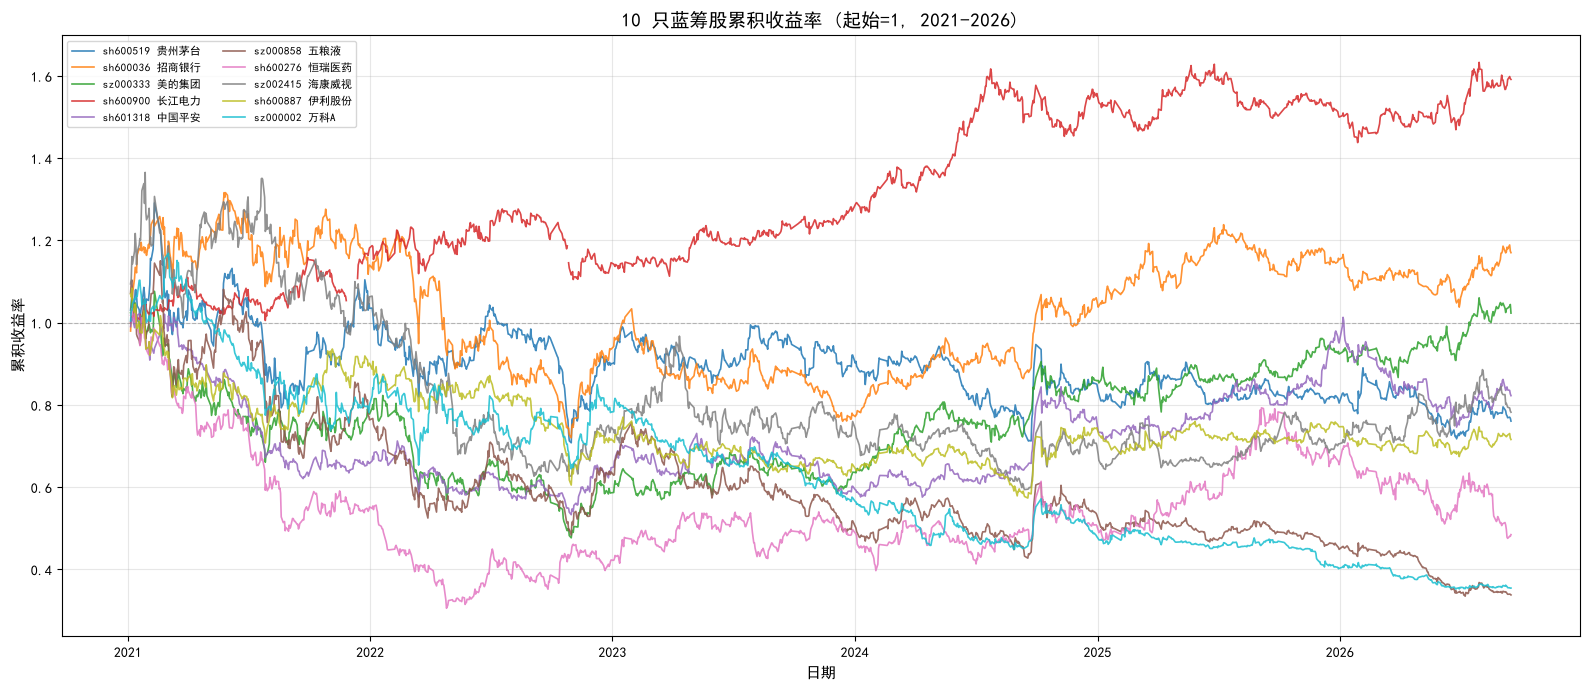

=== 最终累积收益 (截至最新) ===
  sh600900 (长江电力): 1 元变为 1.59 元 (总收益 +59.2%)
  sh600036 (招商银行): 1 元变为 1.17 元 (总收益 +17.0%)
  sz000333 (美的集团): 1 元变为 1.02 元 (总收益 +2.3%)
  sh601318 (中国平安): 1 元变为 0.82 元 (总收益 -17.8%)
  sz002415 (海康威视): 1 元变为 0.78 元 (总收益 -21.8%)
  sh600519 (贵州茅台): 1 元变为 0.76 元 (总收益 -23.9%)
  sh600887 (伊利股份): 1 元变为 0.72 元 (总收益 -28.4%)
  sh600276 (恒瑞医药): 1 元变为 0.48 元 (总收益 -51.5%)
  sz000002 (万科A): 1 元变为 0.35 元 (总收益 -64.5%)
  sz000858 (五粮液): 1 元变为 0.34 元 (总收益 -66.2%)


In [5]:
# ============================================
# 图2: 累积收益率 (起始=1)
# ============================================
cum_returns = (1 + return_matrix).cumprod()

fig, ax = plt.subplots(figsize=(16, 7))
for sym, c in zip(SYMBOLS, colors):
    name = STOCK_INFO[sym][0]
    ax.plot(cum_returns.index, cum_returns[sym],
            label=f'{sym} {name}', linewidth=1.2, color=c, alpha=0.85)

ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('10 只蓝筹股累积收益率 (起始=1, 2021-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('日期', fontsize=11)
ax.set_ylabel('累积收益率', fontsize=11)
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('=== 最终累积收益 (截至最新) ===')
final = cum_returns.iloc[-1].sort_values(ascending=False)
for sym, val in final.items():
    name = STOCK_INFO[sym][0]
    print(f'  {sym} ({name}): 1 元变为 {val:.2f} 元 (总收益 {(val-1)*100:+.1f}%)')


### 图 3：20 日滚动年化波动率

计算每只股票过去 20 个交易日的标准差并年化（$\times \sqrt{252}$），观察风险水平的时变特征。


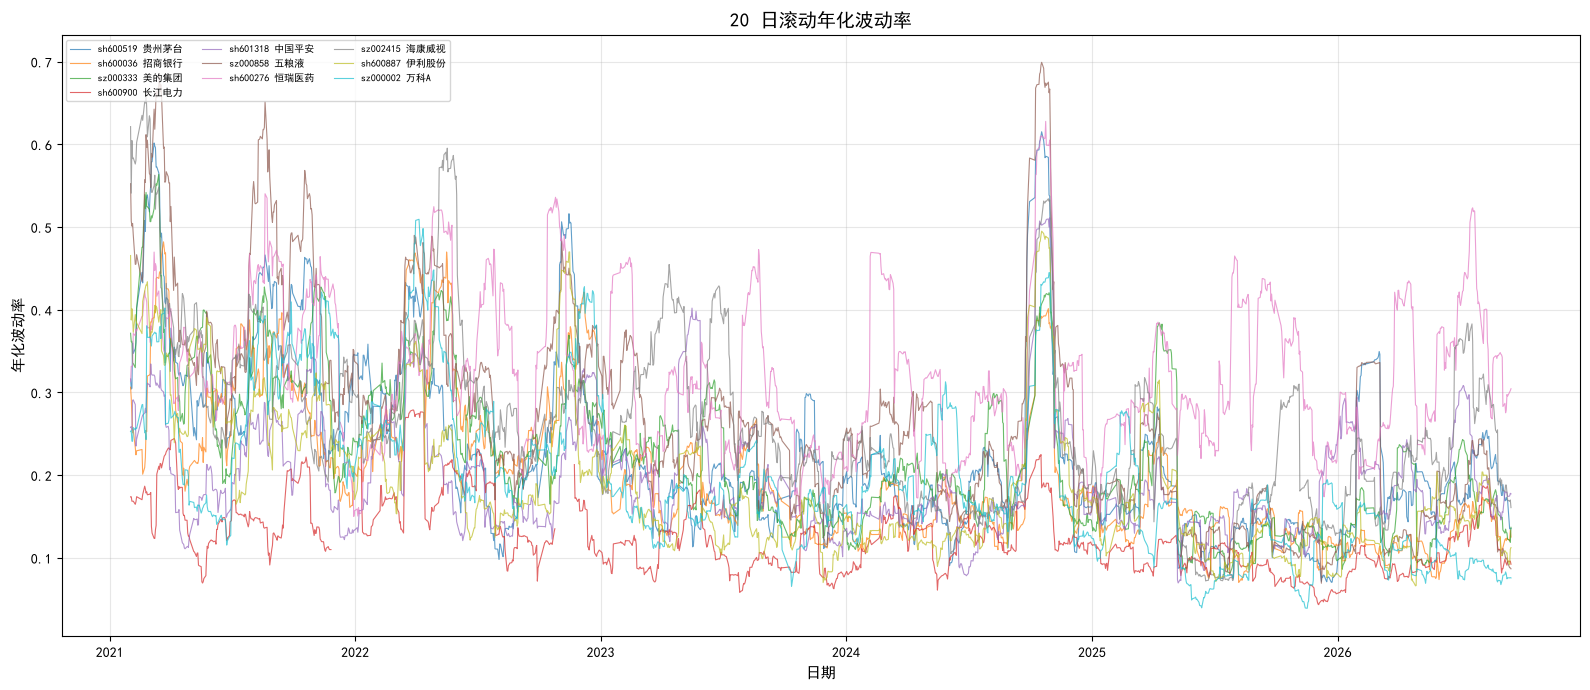

In [6]:
# ============================================
# 图3: 20 日滚动年化波动率
# ============================================
TRADING_DAYS = 252
rolling_vol = return_matrix.rolling(window=20).std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(16, 7))
for sym, c in zip(SYMBOLS, colors):
    name = STOCK_INFO[sym][0]
    ax.plot(rolling_vol.index, rolling_vol[sym],
            label=f'{sym} {name}', linewidth=0.8, color=c, alpha=0.7)

ax.set_title('20 日滚动年化波动率', fontsize=14, fontweight='bold')
ax.set_xlabel('日期', fontsize=11)
ax.set_ylabel('年化波动率', fontsize=11)
ax.legend(loc='upper left', fontsize=7, ncol=3, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 图 4：日收益率相关性热力图

计算 10 只股票日收益率的 Pearson 相关系数矩阵。同行业（如白酒的茅台和五粮液、金融的招行和平安）预期有较高相关性。


findfont: Failed to find font weight bold for SimHei, now using 400.


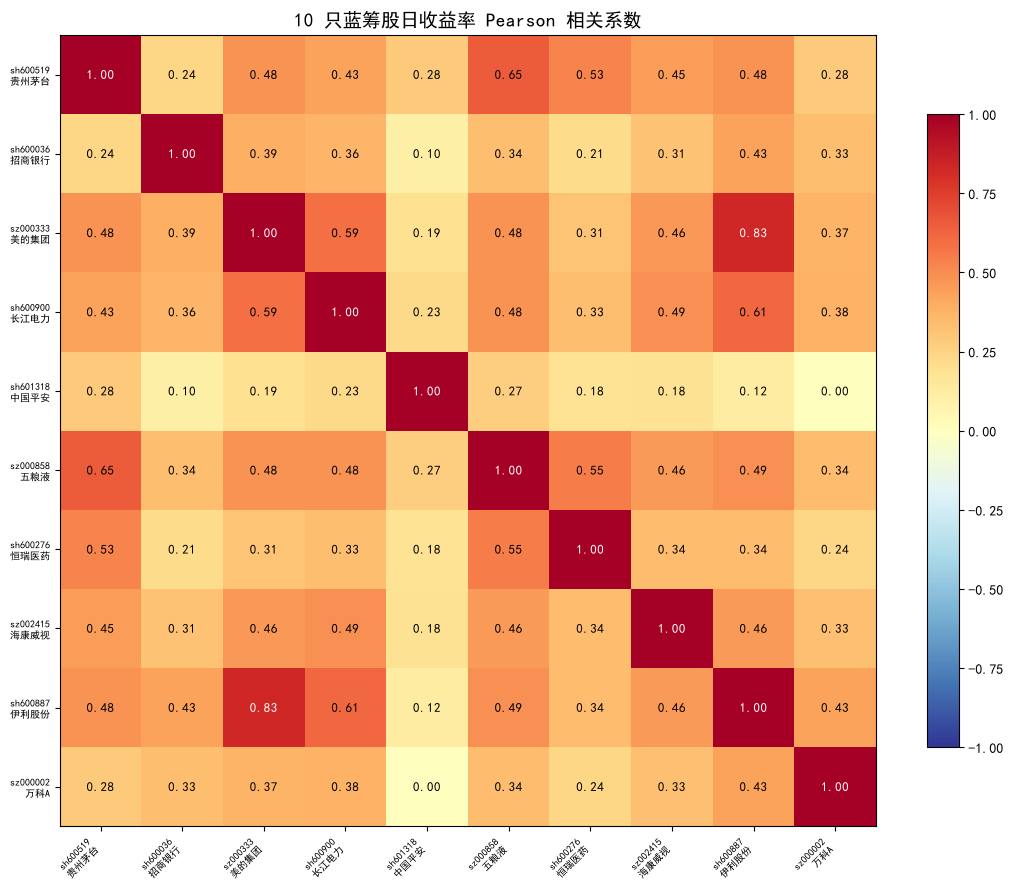

=== 同行业股票相关性 ===
茅台 vs 五粮液 (白酒): 0.830
招商银行 vs 中国平安 (金融): 0.654

相关系数矩阵 (保留3位):
symbol    sh600036  sh600276  sh600519  sh600887  sh600900  sh601318  sz000002  sz000333  sz000858  sz002415
symbol                                                                                                      
sh600036     1.000     0.241     0.482     0.433     0.284     0.654     0.527     0.451     0.480     0.283
sh600276     0.241     1.000     0.388     0.361     0.095     0.335     0.214     0.313     0.431     0.329
sh600519     0.482     0.388     1.000     0.588     0.195     0.483     0.308     0.463     0.830     0.371
sh600887     0.433     0.361     0.588     1.000     0.225     0.484     0.330     0.486     0.615     0.376
sh600900     0.284     0.095     0.195     0.225     1.000     0.268     0.176     0.182     0.125     0.001
sh601318     0.654     0.335     0.483     0.484     0.268     1.000     0.547     0.459     0.487     0.343
sz000002     0.527     0.214     0.308     0.330

In [7]:
# ============================================
# 图4: 日收益率相关性热力图
# ============================================
corr_matrix = common_dates.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')

labels = [f'{sym}\n{STOCK_INFO[sym][0]}' for sym in SYMBOLS]
ax.set_xticks(range(len(SYMBOLS)))
ax.set_yticks(range(len(SYMBOLS)))
ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=7)

for i in range(len(SYMBOLS)):
    for j in range(len(SYMBOLS)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)

ax.set_title('10 只蓝筹股日收益率 Pearson 相关系数', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print('=== 同行业股票相关性 ===')
print(f'茅台 vs 五粮液 (白酒): {corr_matrix.loc["sh600519","sz000858"]:.3f}')
print(f'招商银行 vs 中国平安 (金融): {corr_matrix.loc["sh600036","sh601318"]:.3f}')
print()
print('相关系数矩阵 (保留3位):')
print(corr_matrix.round(3).to_string())


### 图形分析综合解读

**收盘价走势**：多数股票在 2021-2023 年经历回调，反映 A 股整体下行趋势。电力（长江电力）表现出防御属性。

**累积收益**：行业间差异显著——公用事业和消费龙头相对稳健，房地产受行业逆风影响较大。

**滚动波动率**：所有股票均表现出波动率聚类——大波动之后跟着大波动，这是金融数据的典型特征。

**相关性**：整体相关系数在 0.2~0.7 之间。同行业高度联动（茅台/五粮液），跨行业也存在中等系统性风险。跨行业配置能降低部分非系统性风险，但不能消除市场整体风险。


---
## Step 5：年化指标

- **年化收益率**：$R_{ann} = [\prod(1+r_t)]^{252/T} - 1$（复利口径）
- **年化波动率**：$\sigma_{ann} = \sigma_{daily} \times \sqrt{252}$
- **夏普比率**：$(R_{ann} - r_f) / \sigma_{ann}$，$r_f = 2\%$

$T$ 为每只股票实际交易日数（不含停牌缺失）。


In [8]:
# ============================================
# 年化指标统计
# ============================================
RISK_FREE = 0.02

stats = []
for sym in SYMBOLS:
    r = return_matrix[sym].dropna()
    T = len(r)
    if T == 0:
        continue
    name, ind = STOCK_INFO[sym]
    cum_total = (1 + r).prod()
    ann_return = cum_total ** (TRADING_DAYS / T) - 1
    daily_std = r.std()
    ann_vol = daily_std * np.sqrt(TRADING_DAYS)
    sharpe = (ann_return - RISK_FREE) / ann_vol if ann_vol > 0 else np.nan

    stats.append({
        '代码': sym, '名称': name, '行业': ind,
        '交易日数': T, '年化收益率': ann_return,
        '年化波动率': ann_vol, '夏普比率': sharpe,
        '日均收益率': r.mean(), '日波动率': daily_std,
    })

stats_df = pd.DataFrame(stats).sort_values('夏普比率', ascending=False)

print(f'=== 各股票年化指标汇总 ===')
print(f'无风险利率: {RISK_FREE:.0%}，年交易日: {TRADING_DAYS} 天')
print()
print(f'{"代码":<12} {"名称":<8} {"行业":<6} {"年化收益":>10} {"年化波动":>10} {"夏普":>8}')
print('-' * 60)
for _, row in stats_df.iterrows():
    print(f'{row["代码"]:<12} {row["名称"]:<8} {row["行业"]:<6} '
          f'{row["年化收益率"]:>9.2%}  {row["年化波动率"]:>9.2%}  {row["夏普比率"]:>7.3f}')

print()
print(f'年化收益率均值: {stats_df["年化收益率"].mean():.2%}')
print(f'年化波动率均值: {stats_df["年化波动率"].mean():.2%}')
print(f'夏普比率均值:   {stats_df["夏普比率"].mean():.3f}')


=== 各股票年化指标汇总 ===
无风险利率: 2%，年交易日: 252 天

代码           名称       行业           年化收益       年化波动       夏普
------------------------------------------------------------
sh600900     长江电力     电力         8.91%     13.31%    0.519
sh600036     招商银行     银行         2.91%     22.17%    0.041
sz000333     美的集团     家电         0.42%     24.09%   -0.066
sz002415     海康威视     科技        -4.38%     28.29%   -0.225
sh601318     中国平安     保险        -3.50%     20.74%   -0.265
sh600519     贵州茅台     白酒        -4.87%     24.94%   -0.275
sh600887     伊利股份     食品        -5.91%     20.82%   -0.380
sh600276     恒瑞医药     医药       -12.37%     33.25%   -0.432
sz000858     五粮液      白酒       -17.94%     29.93%   -0.666
sz000002     万科A      房地产      -17.22%     21.82%   -0.881

年化收益率均值: -5.39%
年化波动率均值: 23.94%
夏普比率均值:   -0.263


### 年化指标解读

- **年化收益率**：正值表示总体上涨。行业间差异显著，反映不同行业的景气度差异。
- **年化波动率**：通常在 20%~50%。高波动不一定意味着高收益——A 股市场风险-收益关系并非简单的线性对应。
- **夏普比率**：正值表示跑赢无风险利率。夏普比率较高的股票提供更好的风险调整后回报。

理论上（CAPM）风险越高回报越高，但 A 股实际数据常不完全支持——原因包括市场情绪、政策干预、行业周期等。


---
## Step 6：投资组合构建

### 组合一：等权重 (Equal-Weight)

每只股票每日配比 $w_i = 1/10$：

$$r^{EW}_{p,t} = \sum_{i=1}^{10} 0.1 \cdot r_{i,t}$$

操作简单、不依赖额外数据，是最朴素的分散化方式。


In [9]:
# ============================================
# 等权重组合
# ============================================
N = len(SYMBOLS)
ew_weights = np.ones(N) / N

ew_daily = common_dates @ ew_weights
T_common = len(ew_daily)

ew_cum = (1 + ew_daily).prod()
ew_ann_return = ew_cum ** (TRADING_DAYS / T_common) - 1
ew_ann_vol = ew_daily.std() * np.sqrt(TRADING_DAYS)
ew_sharpe = (ew_ann_return - RISK_FREE) / ew_ann_vol

print('=== 等权重组合 ===')
print('各股票权重: 均为 10.00%')
print(f'共同交易日: {T_common}')
print(f'年化收益率: {ew_ann_return:.2%}')
print(f'年化波动率: {ew_ann_vol:.2%}')
print(f'夏普比率:   {ew_sharpe:.3f}')
print(f'累计总收益: {ew_cum-1:.2%}')


=== 等权重组合 ===
各股票权重: 均为 10.00%
共同交易日: 1372
年化收益率: -5.10%
年化波动率: 16.07%
夏普比率:   -0.442
累计总收益: -24.80%


### 组合二：市值加权 (Value-Weight)

按每日市值占比配置：

$$w_{i,t-1} = \frac{MV_{i,t-1}}{\sum MV_{j,t-1}}, \quad r^{VW}_{p,t} = \sum w_{i,t-1} \cdot r_{i,t}$$

AKShare 日线接口不直接提供历史市值。此处用**日成交额作为市值代理**构建权重（两者高度正相关，适合教学演示）。正式研究应使用 CSMAR 或 Wind 的总市值数据。


In [10]:
# ============================================
# 市值加权组合（日成交额代理）
# ============================================

amount_matrix = returns.pivot_table(
    values='amount', index='date', columns='symbol'
)

# 平移一天：t 日的权重基于 t-1 日成交额
amount_lagged = amount_matrix.shift(1)

# 每日权重
vw_weights = amount_lagged.div(amount_lagged.sum(axis=1), axis=0)

# 与收益率对齐
common_idx = common_dates.index
vw_w = vw_weights.loc[vw_weights.index.isin(common_idx)]
vw_r = common_dates.loc[vw_w.index]
vw_daily = (vw_r * vw_w).sum(axis=1).dropna()

T_vw = len(vw_daily)
vw_cum = (1 + vw_daily).prod()
vw_ann_return = vw_cum ** (TRADING_DAYS / T_vw) - 1
vw_ann_vol = vw_daily.std() * np.sqrt(TRADING_DAYS)
vw_sharpe = (vw_ann_return - RISK_FREE) / vw_ann_vol

print('=== 市值加权组合 (成交额代理) ===')
print(f'有效交易日: {T_vw}')
print(f'年化收益率: {vw_ann_return:.2%}')
print(f'年化波动率: {vw_ann_vol:.2%}')
print(f'夏普比率:   {vw_sharpe:.3f}')
print(f'累计总收益: {vw_cum-1:.2%}')
print()

print('=== 平均权重分布 ===')
avg_w = vw_w.mean()
for sym in SYMBOLS:
    name = STOCK_INFO[sym][0]
    print(f'  {sym} ({name}): {avg_w[sym]:.1%}')
print(f'HHI 集中度: {(avg_w**2).sum():.3f}')


=== 市值加权组合 (成交额代理) ===
有效交易日: 1372
年化收益率: -7.61%
年化波动率: 18.13%
夏普比率:   -0.530
累计总收益: -35.00%

=== 平均权重分布 ===
  sh600519 (贵州茅台): 21.5%
  sh600036 (招商银行): 10.4%
  sz000333 (美的集团): 8.2%
  sh600900 (长江电力): 7.3%
  sh601318 (中国平安): 13.0%
  sz000858 (五粮液): 13.1%
  sh600276 (恒瑞医药): 8.9%
  sz002415 (海康威视): 6.3%
  sh600887 (伊利股份): 5.8%
  sz000002 (万科A): 5.6%
HHI 集中度: 0.121


### 组合构建解读

- **等权重**：所有股票一视同仁。透明、分散，但可能低配大市值龙头。
- **市值加权**：更贴近沪深300等实际指数的构造方式。大市值股票主导组合表现。

**市值代理局限**：日成交额受当天交易活跃度影响，波动较大。高换手率股票（如科技股）可能被过度配置。结论仅供教学参考，正式研究需使用真实市值。


findfont: Failed to find font weight bold for SimHei, now using 400.


=== 两种组合对比 (对齐后) ===
对齐后共同交易日: 1372

指标                            等权重         市值加权           差异
--------------------------------------------------------
年化收益率                     -5.10%       -7.61%       -2.51%
年化波动率                     16.07%       18.13%        2.07%
夏普比率                      -0.442       -0.530       -0.088


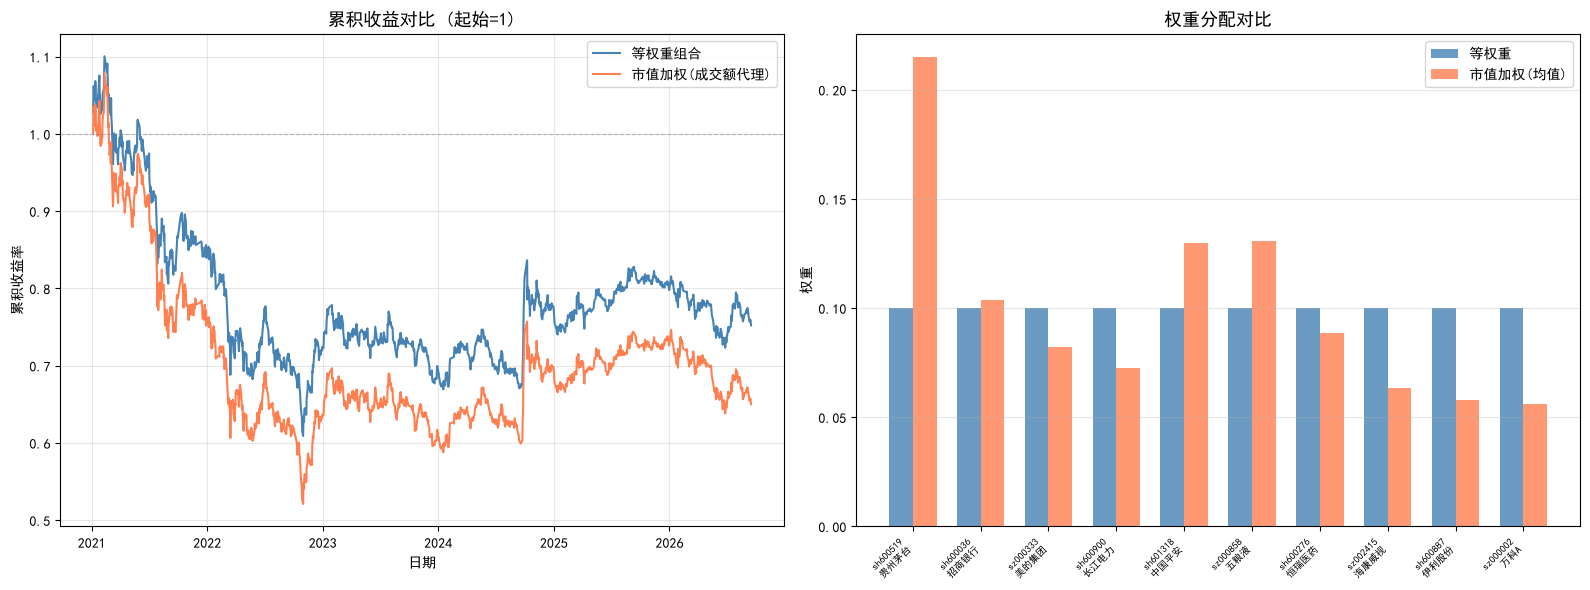

In [11]:
# ============================================
# 两种组合对比
# ============================================

# 对齐日期
combined_df = pd.DataFrame({'等权重': ew_daily, '市值加权': vw_daily}).dropna()
T_aligned = len(combined_df)

ew_a2 = (1 + combined_df['等权重']).prod() ** (TRADING_DAYS / T_aligned) - 1
ew_v2 = combined_df['等权重'].std() * np.sqrt(TRADING_DAYS)
ew_s2 = (ew_a2 - RISK_FREE) / ew_v2

vw_a2 = (1 + combined_df['市值加权']).prod() ** (TRADING_DAYS / T_aligned) - 1
vw_v2 = combined_df['市值加权'].std() * np.sqrt(TRADING_DAYS)
vw_s2 = (vw_a2 - RISK_FREE) / vw_v2

print('=== 两种组合对比 (对齐后) ===')
print(f'对齐后共同交易日: {T_aligned}')
print()
print(f'{"指标":<20} {"等权重":>12} {"市值加权":>12} {"差异":>12}')
print('-' * 56)
print(f'{"年化收益率":<20} {ew_a2:>11.2%}  {vw_a2:>11.2%}  {vw_a2-ew_a2:>11.2%}')
print(f'{"年化波动率":<20} {ew_v2:>11.2%}  {vw_v2:>11.2%}  {vw_v2-ew_v2:>11.2%}')
print(f'{"夏普比率":<20} {ew_s2:>11.3f}  {vw_s2:>11.3f}  {vw_s2-ew_s2:>11.3f}')

# 累积收益对比图
cum_ew = (1 + combined_df['等权重']).cumprod()
cum_vw = (1 + combined_df['市值加权']).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(cum_ew.index, cum_ew, label='等权重组合', linewidth=1.5, color='steelblue')
ax.plot(cum_vw.index, cum_vw, label='市值加权(成交额代理)', linewidth=1.5, color='coral')
ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('累积收益对比 (起始=1)', fontsize=13, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('累积收益率')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
x = np.arange(N)
width = 0.35
labels = [f'{sym}\n{STOCK_INFO[sym][0]}' for sym in SYMBOLS]
ax.bar(x - width/2, ew_weights, width, label='等权重', color='steelblue', alpha=0.8)
ax.bar(x + width/2, [avg_w[sym] for sym in SYMBOLS],
       width, label='市值加权(均值)', color='coral', alpha=0.8)
ax.set_ylabel('权重')
ax.set_title('权重分配对比', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 组合对比解读

**两者差异的可能原因**：

1. **权重集中度**：市值加权集中在少数大盘股，组合表现更依赖重仓股。
2. **行业偏向**：市值加权天然偏向大市值行业（金融、白酒），等权重更均衡。
3. **代理误差**：成交额≠市值，高换手率股票可能被过度配置。

**投资含义**：

- 等权重分散更均匀，但理论调仓成本更高
- 市值加权更贴近被动指数投资、更实际可行
- 5 年回测不代表未来表现——样本期选择对结论有重大影响
- 两者夏普比率的差异反映了不同配置理念的风险调整后效率


---
## HW02-1 小结

### 做了什么

1. 从 AKShare 下载 10 只蓝筹股（9 行业）2021-2026 年后复权日线数据
2. 执行完整数据质量检查（唯一性、缺失、异常值、单位）
3. 计算日收益率，生成 4 张分析图表
4. 统计年化指标（收益率、波动率、夏普比率）
5. 构建等权重和市值加权两种投资组合并对比

### 主要发现

1. **A 股高相关性**：10 只蓝筹股相关系数 0.2~0.7，同行业更高。跨行业配置能降低但无法消除系统性风险。
2. **波动率聚类**：所有股票均表现出"大波动→大波动"特征。
3. **两组合差异**：取决于样本期各行业/市值的相对表现。

### 局限

1. **市值代理**：成交额替代市值是不完美的近似，正式研究需使用真实市值
2. **事后偏差**：只选了存活至今的蓝筹，未考虑退市/衰落
3. **时期依赖**：2021-2026 有其特殊性（疫后、地产下行等）
4. **零成本假设**：忽略交易摩擦和冲击成本


---
## 复现说明

### 数据文件

| 文件 | 用途 | 来源 |
|---|---|---|
| `data/prices.csv` | 10 只股票后复权日线 | AKShare, 2026-09-18 |
| `data/download_stocks.py` | 数据下载脚本 | 本仓库 |

### 运行环境

- Python 3.14.7
- pandas, numpy, matplotlib, akshare
- Windows 11
- 教师仓库: https://github.com/lianxhcn/FinEco
- 作业仓库: https://github.com/jianghzt/FinEco-homework

### 复现步骤

1. `git clone https://github.com/jianghzt/FinEco-homework.git`
2. `pip install pandas numpy matplotlib akshare`
3. 数据已附带于 `data/prices.csv`，无需重新下载
4. 打开本 Notebook → Restart Kernel & Run All → 验证输出

如需重新下载数据：
```python
import akshare as ak
df = ak.stock_zh_a_hist(symbol='600519', period='daily',
                         start_date='20201231', end_date='20260916',
                         adjust='hfq')
```


---
## AI 使用声明

本作业使用 **OpenAI Codex (GPT-5)** 辅助完成。

### AI 协助内容
- Notebook 框架与代码生成
- AKShare 数据下载（含接口切换与重试）
- 数据检查逻辑
- 图表代码与参数
- 组合构建计算
- 文字说明初稿

### 本人独立完成
- 10 只股票选择（行业分布、代表性判断）
- 数据下载执行与调试
- 运行、核验与修正
- 结果理解与文字修改
- 合理性判断

### 关键提示词（部分）
- "重新仔细阅读作业要求，修改完成 HW02-1"
- "10 只股票选择能够代表大盘的权重股或蓝筹股"
- "通过 AKShare 下载后复权数据"
- "构建等权重和市值加权两种投资组合"

### 帮助
大幅提升代码编写调试效率，使我专注分析逻辑理解与结果解读。所有 AI 产出均经本人审核修改。

对话记录保存在 Codex 会话中。
